In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import ttest_ind

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [42]:
trades = pd.read_csv("dataset/historical_data (5).csv")
fear = pd.read_csv("dataset/fear_greed_index.csv")

In [43]:
print("Trades Shape :", trades.shape)
print("Fear Shape :", fear.shape)

trades.head()

Trades Shape : (211224, 16)
Fear Shape : (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [44]:
fear.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [45]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [46]:
fear.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [47]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [48]:
fear.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [49]:
print(trades.duplicated().sum())
print(fear.duplicated().sum())

0
0


In [50]:
trades.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [51]:
fear.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [52]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [53]:
# Convert timestamps to datetime

trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

fear["date"] = pd.to_datetime(fear["date"])

# Extract only the date part

trades["Date"] = trades["Timestamp IST"].dt.date

fear["Date"] = fear["date"].dt.date

In [54]:
trades["Date"] = trades["Timestamp IST"].dt.date
fear["Date"] = fear["date"].dt.date

merged = trades.merge(
    fear[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [55]:
# Winning and Losing trades
merged["IsWin"] = merged["Closed PnL"] > 0
merged["IsLoss"] = merged["Closed PnL"] < 0

# Absolute Profit/Loss
merged["AbsPnL"] = merged["Closed PnL"].abs()

# Trade Value
merged["TradeValue"] = merged["Execution Price"] * merged["Size Tokens"]

# Return Percentage
merged["PnLPercent"] = (merged["Closed PnL"] / merged["Size USD"]) * 100

In [56]:
print("Rows:", merged.shape[0])
print("Columns:", merged.shape[1])

merged.describe(include="all")

Rows: 211224
Columns: 24


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value,IsWin,IsLoss,AbsPnL,TradeValue,PnLPercent
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211218,211218.000000,211224,211224,211224.000000,2.112240e+05,211181.000000
unique,32,246,NaN,NaN,NaN,2,NaN,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,480,5,NaN,2,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,NaN,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,2025-02-25,Fear,NaN,False,False,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,NaN,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,6246,61837,NaN,124355,193685,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,2025-01-31 12:04:22.915010,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12,NaN,NaN,51.649656,NaN,NaN,76.669947,5.639451e+03,1.899493
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,2023-05-01 01:06:00,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12,NaN,NaN,10.000000,NaN,NaN,0.000000,1.627190e-07,-38440.642609
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,2024-12-31 21:00:45,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12,NaN,NaN,33.000000,NaN,NaN,0.000000,1.937895e+02,0.000000
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,2025-02-24 18:55:00,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12,NaN,NaN,49.000000,NaN,NaN,0.000000,5.970446e+02,0.000000
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,2025-04-02 18:22:00,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12,NaN,NaN,72.000000,NaN,NaN,10.735428,2.058961e+03,1.032304
max,NaN,NaN,109004.000000,1.582244e+07,3.921431e+06,NaN,2025-05-01 12:13:00,3.050948e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12,NaN,NaN,94.000000,NaN,NaN,135329.090100,3.921431e+06,340.354950


In [57]:
merged = merged.dropna(subset=["classification"])

In [58]:
merged["PnLPercent"] = np.where(
    merged["Size USD"] > 0,
    merged["Closed PnL"] / merged["Size USD"] * 100,
    np.nan
)

In [59]:
summary = merged.groupby("classification").agg(
    Trades=("Closed PnL","count"),
    TotalPnL=("Closed PnL","sum"),
    AvgPnL=("Closed PnL","mean"),
    MedianPnL=("Closed PnL","median"),
    WinRate=("IsWin","mean"),
    AvgFee=("Fee","mean"),
    AvgTradeSize=("Size USD","mean")
)

summary["WinRate"] *= 100

summary.round(2)

,Trades,TotalPnL,AvgPnL,MedianPnL,WinRate,AvgFee,AvgTradeSize
classification,,,,,,,
Extreme Fear,21400,739110.25,34.54,0.0,37.06,1.12,5349.73
Extreme Greed,39992,2715171.31,67.89,0.0,46.49,0.68,3112.25
Fear,61837,3357155.44,54.29,0.0,42.08,1.50,7816.11
Greed,50303,2150129.27,42.74,0.0,38.48,1.25,5736.88
Neutral,37686,1292920.68,34.31,0.0,39.70,1.04,4782.73


In [124]:
from scipy.stats import f_oneway

groups = [
    g["Closed PnL"].values
    for _, g in merged.groupby("classification")
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")
print()

print("""Interpretation of ANOVA Test

1.A one-way Analysis of Variance (ANOVA) was performed to examine whether the average Closed PnL differs across the five market sentiment 
categories (Extreme Fear, Fear, Neutral, Greed, and Extreme Greed).

2.The analysis produced an F-statistic of 9.062 and a p-value less than 0.001. Since the p-value is significantly lower than the commonly 
used significance level of 0.05, the null hypothesis is rejected.

3.This result indicates that the average trading profitability is not the same across all market sentiment categories. In other words, 
market sentiment has a statistically significant impact on trader performance. However, the ANOVA test does not identify which specific sentiment groups differ from one another. Therefore, a Tukey HSD post-hoc test was conducted to determine the sentiment pairs with statistically significant differences.""")

F-statistic: 9.062
P-value: 0.00000

Interpretation of ANOVA Test

1.A one-way Analysis of Variance (ANOVA) was performed to examine whether the average Closed PnL differs across the five market sentiment 
categories (Extreme Fear, Fear, Neutral, Greed, and Extreme Greed).

2.The analysis produced an F-statistic of 9.062 and a p-value less than 0.001. Since the p-value is significantly lower than the commonly 
used significance level of 0.05, the null hypothesis is rejected.

3.This result indicates that the average trading profitability is not the same across all market sentiment categories. In other words, 
market sentiment has a statistically significant impact on trader performance. However, the ANOVA test does not identify which specific sentiment groups differ from one another. Therefore, a Tukey HSD post-hoc test was conducted to determine the sentiment pairs with statistically significant differences.


        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1        group2    meandiff p-adj   lower    upper   reject
--------------------------------------------------------------------
 Extreme Fear Extreme Greed   33.355 0.0002  12.1482  54.5618   True
 Extreme Fear          Fear  19.7525  0.052  -0.1057  39.6108  False
 Extreme Fear         Greed   8.2057 0.8091 -12.2295  28.6409  False
 Extreme Fear       Neutral  -0.2301    1.0 -21.6619  21.2017  False
Extreme Greed          Fear -13.6025 0.1418 -29.6696   2.4647  False
Extreme Greed         Greed -25.1493 0.0004 -41.9243  -8.3743   True
Extreme Greed       Neutral -33.5851    0.0 -51.5608 -15.6095   True
         Fear         Greed -11.5468 0.2221 -26.5808   3.4871  False
         Fear       Neutral -19.9827 0.0077 -36.3456  -3.6198   True
        Greed       Neutral  -8.4358 0.6604 -25.4943   8.6226  False
--------------------------------------------------------------------


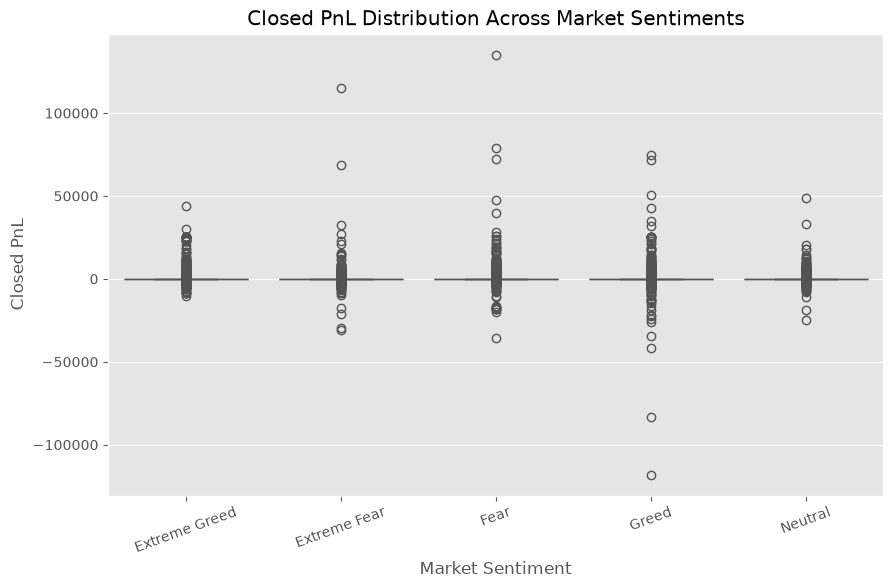

Interpretation
1.The statistical analysis confirms that market sentiment influences trading outcomes, but the effect is not uniform across all sentiment categories.
2.Trading strategies that adapt to significant shifts in market sentiment—particularly during transitions involving Extreme Greed and Extreme Fear—may achieve more consistent performance.
3.These findings support incorporating market sentiment indicators into risk management and decision-making processes rather than relying solely on price movements.


In [120]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=merged["Closed PnL"],
    groups=merged["classification"],
    alpha=0.05
)

print(tukey)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=20)

plt.show()

print("""Interpretation
1.The statistical analysis confirms that market sentiment influences trading outcomes, but the effect is not uniform across all sentiment categories.
2.Trading strategies that adapt to significant shifts in market sentiment—particularly during transitions involving Extreme Greed and Extreme Fear—may achieve more consistent performance.
3.These findings support incorporating market sentiment indicators into risk management and decision-making processes rather than relying solely on price movements.""")

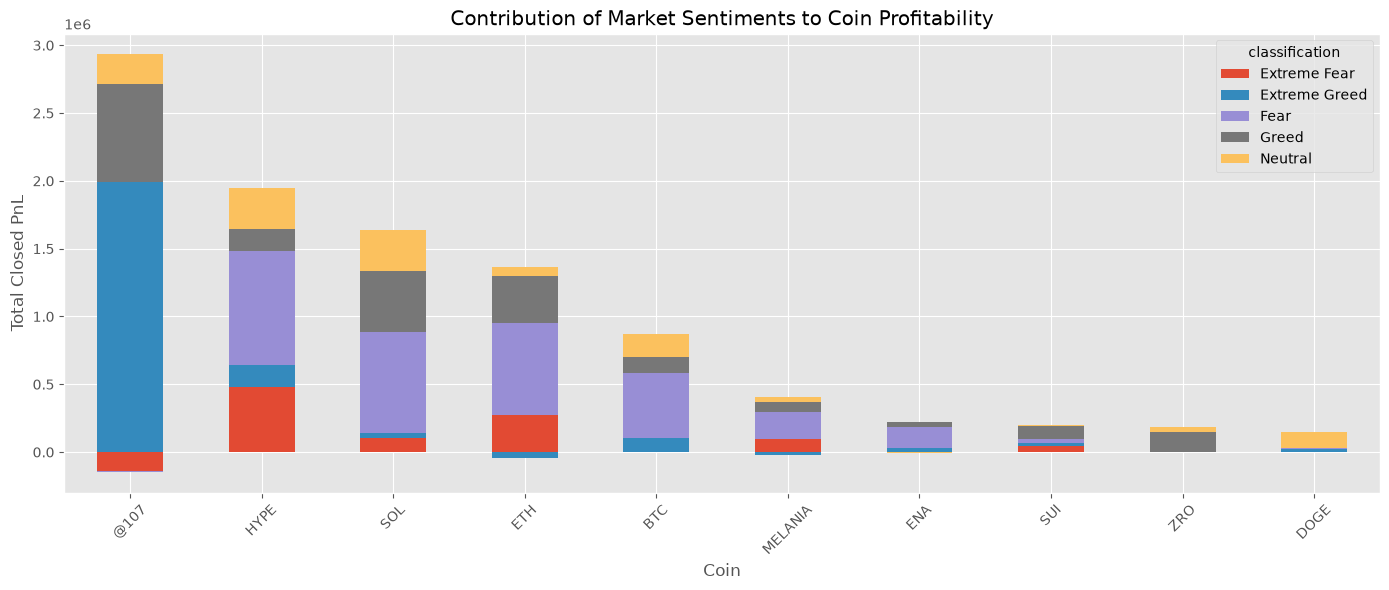

Interpretation
1.The stacked bars show how total profitability for each coin is distributed across different market sentiment categories.
2.This chart reveals whether a coin's overall performance is driven by a single sentiment or is consistently profitable across multiple market conditions.
3.Coins with balanced contributions across sentiments may indicate more stable trading opportunities.


In [118]:
coin_summary = (
    merged
    .groupby(["classification","Coin"])
    ["Closed PnL"]
    .sum()
    .reset_index()
)

coin_summary.sort_values(
    "Closed PnL",
    ascending=False
)
pivot = coin_summary.pivot(
    index="Coin",
    columns="classification",
    values="Closed PnL"
)

pivot = pivot.loc[
    pivot.sum(axis=1).sort_values(ascending=False).head(10).index
]

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6)
)

plt.title("Contribution of Market Sentiments to Coin Profitability")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print("""Interpretation
1.The stacked bars show how total profitability for each coin is distributed across different market sentiment categories.
2.This chart reveals whether a coin's overall performance is driven by a single sentiment or is consistently profitable across multiple market conditions.
3.Coins with balanced contributions across sentiments may indicate more stable trading opportunities.""")

In [63]:
trader_summary = (
    merged
    .groupby("Account")
    .agg(
        Trades=("Closed PnL","count"),
        TotalPnL=("Closed PnL","sum"),
        AvgPnL=("Closed PnL","mean"),
        WinRate=("IsWin","mean")
    )
)

trader_summary["WinRate"] *= 100

trader_summary.sort_values(
    "TotalPnL",
    ascending=False
).head(10)

,Trades,TotalPnL,AvgPnL,WinRate
Account,,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.143383e+06,145.481748,33.713432
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,35.961236
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.401638e+05,44.364091,46.758211
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,68.684419,40.119320
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.360806e+05,20.806305,42.823014
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,6.777471e+05,155.589314,48.622590
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,4.293556e+05,270.034947,34.591195
0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,336.735548,48.423605
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,3.790954e+05,38.319560,81.087638


C:\Users\sonud\AppData\Local\Temp\ipykernel_3688\267054034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


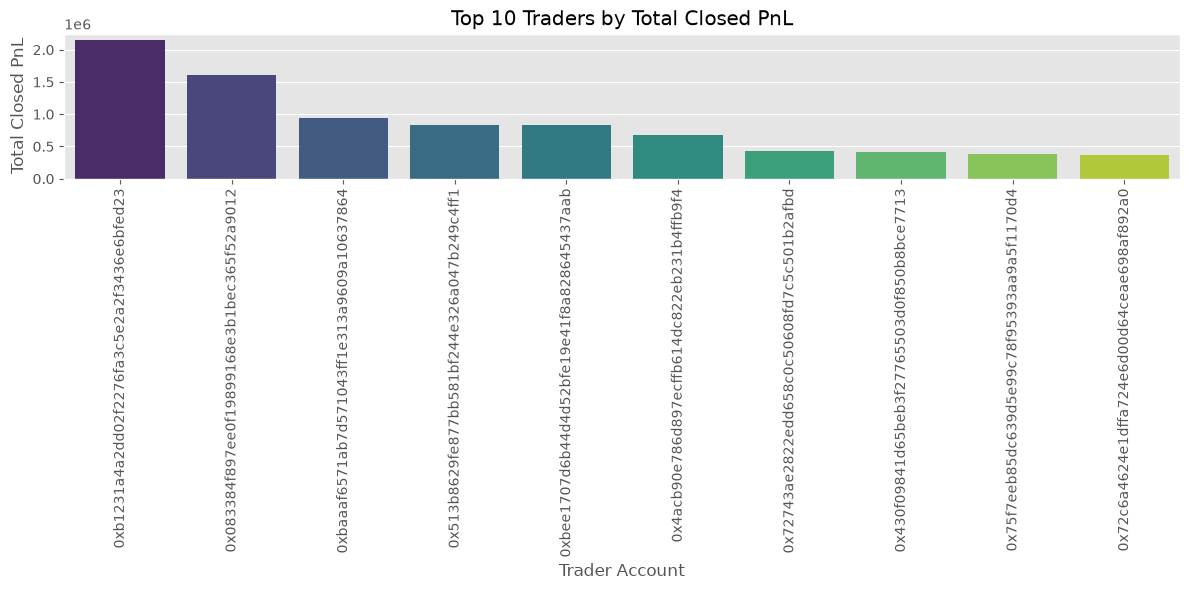

Top 10 Traders by Total Closed PnL
Interpretation
1.This chart ranks the ten traders with the highest cumulative realized profits during the analysis period.
2.The noticeable gap between the top-performing traders and the remaining accounts suggests that profitability is concentrated among a small number of participants.
3.High total profit may result from a combination of effective trading strategies, better risk management, and consistent market participation rather than a few isolated winning trades.


In [114]:
top10 = trader_summary.sort_values(
    by="TotalPnL",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x=top10.index,
    y="TotalPnL",
    palette="viridis"
)

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

print("""Top 10 Traders by Total Closed PnL
Interpretation
1.This chart ranks the ten traders with the highest cumulative realized profits during the analysis period.
2.The noticeable gap between the top-performing traders and the remaining accounts suggests that profitability is concentrated among a small number of participants.
3.High total profit may result from a combination of effective trading strategies, better risk management, and consistent market participation rather than a few isolated winning trades.""")

C:\Users\sonud\AppData\Local\Temp\ipykernel_3688\1762593811.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


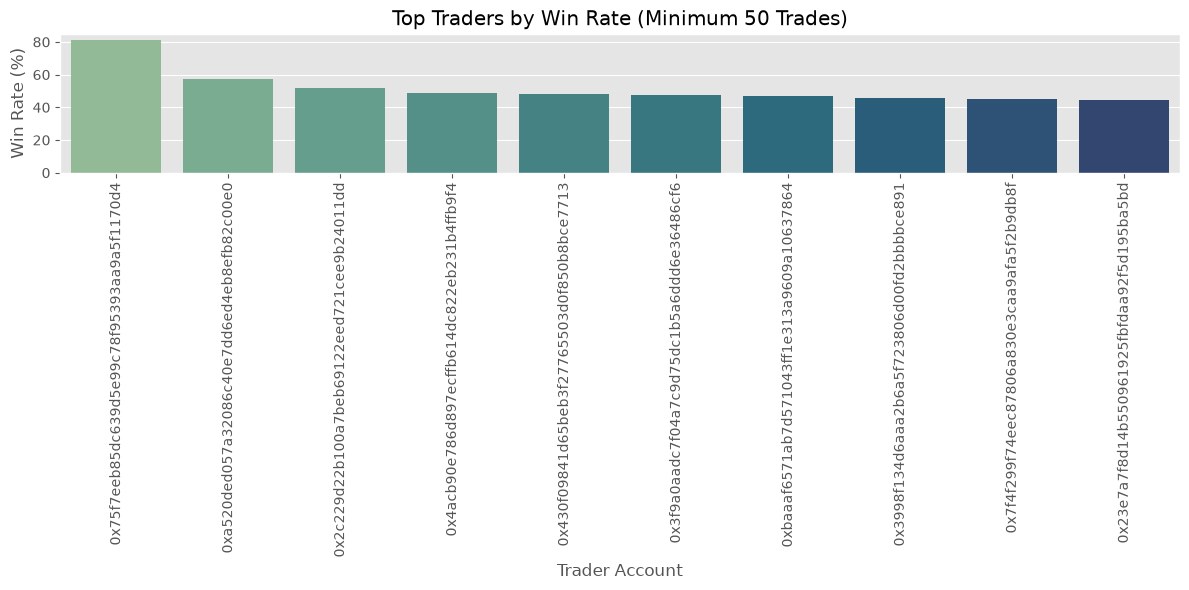

Top 10 Traders by Win Rate (Minimum 50 Trades)
Interpretation
1.This visualization highlights traders with the highest percentage of profitable trades while considering only those with sufficient trading activity.
2.Applying a minimum trade threshold removes traders with very few trades, making the comparison more reliable and statistically meaningful.
3.A high win rate reflects consistency in trade execution; however, it should always be evaluated alongside total profit since frequent small gains can still be offset by occasional large losses.


In [115]:
win_rate = trader_summary[trader_summary["Trades"] >= 50]

top10 = win_rate.sort_values(
    by="WinRate",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x=top10.index,
    y="WinRate",
    palette="crest"
)

plt.title("Top Traders by Win Rate (Minimum 50 Trades)")
plt.xlabel("Trader Account")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()
print("""Top 10 Traders by Win Rate (Minimum 50 Trades)
Interpretation
1.This visualization highlights traders with the highest percentage of profitable trades while considering only those with sufficient trading activity.
2.Applying a minimum trade threshold removes traders with very few trades, making the comparison more reliable and statistically meaningful.
3.A high win rate reflects consistency in trade execution; however, it should always be evaluated alongside total profit since frequent small gains can still be offset by occasional large losses.""")

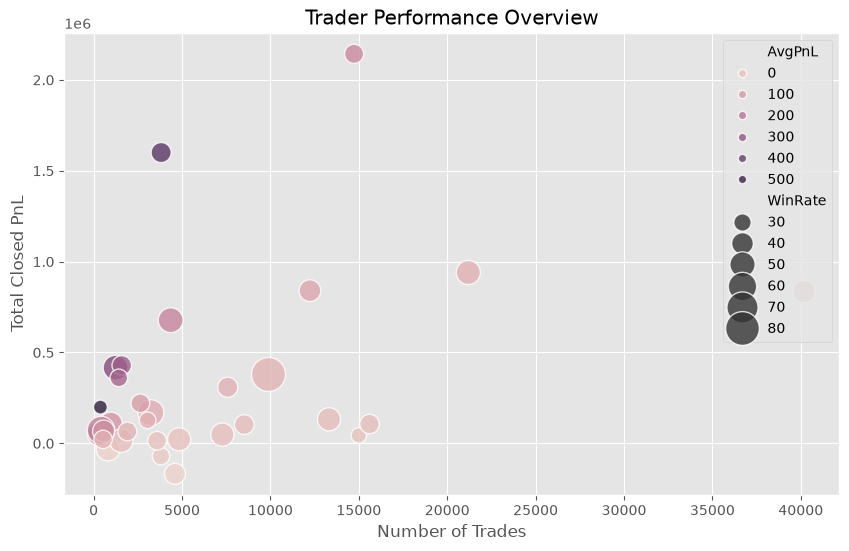

Trader Performance Overview (Scatter Plot)
Interpretation
1.This scatter plot provides a comprehensive view of trader performance by simultaneously displaying trading activity, cumulative profit, average profit per trade, and win rate.
2.Traders positioned in the upper-right region combine high trading frequency with strong profitability, indicating consistently successful performance over many trades.
3.The variation in bubble size and color shows that executing more trades does not necessarily guarantee higher profitability, emphasizing the importance of trading efficiency and strategy quality.


In [116]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=trader_summary,
    x="Trades",
    y="TotalPnL",
    size="WinRate",
    hue="AvgPnL",
    sizes=(100,600),
    alpha=0.8
)

plt.title("Trader Performance Overview")
plt.xlabel("Number of Trades")
plt.ylabel("Total Closed PnL")

plt.show()
print("""Trader Performance Overview (Scatter Plot)
Interpretation
1.This scatter plot provides a comprehensive view of trader performance by simultaneously displaying trading activity, cumulative profit, average profit per trade, and win rate.
2.Traders positioned in the upper-right region combine high trading frequency with strong profitability, indicating consistently successful performance over many trades.
3.The variation in bubble size and color shows that executing more trades does not necessarily guarantee higher profitability, emphasizing the importance of trading efficiency and strategy quality.""")

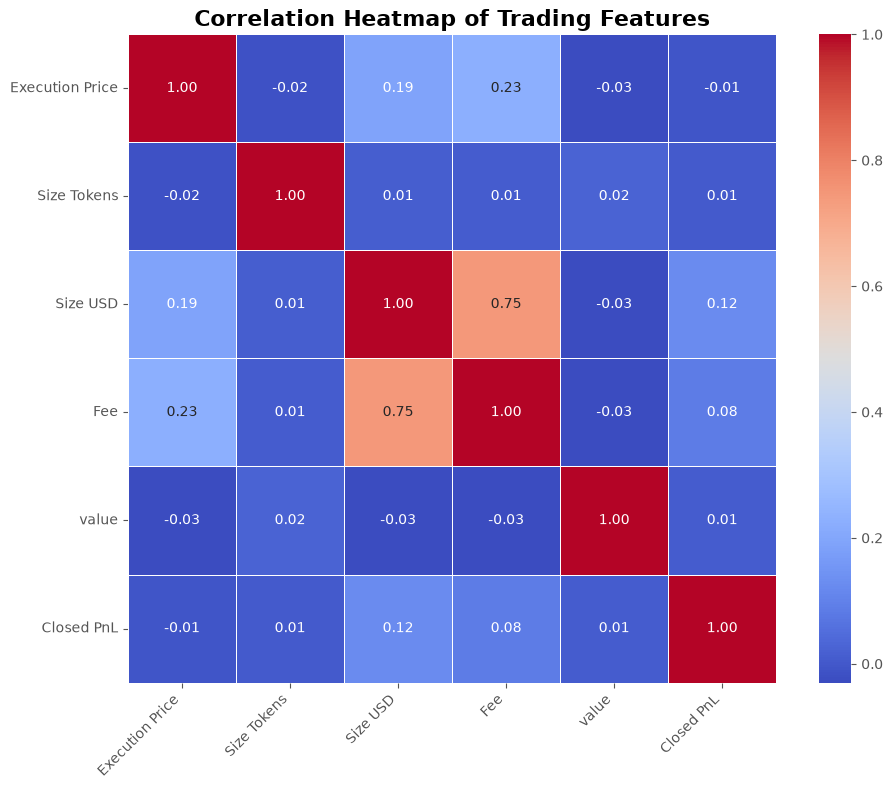

Interpretation 
.The heatmap shows the linear relationship between numerical trading variables.
.Size USD, Size Tokens, and Fee exhibit strong positive correlations, indicating that larger trades generally incur higher transaction fees.
.Closed PnL has relatively weak correlations with the other variables, suggesting that profitability is influenced by factors beyond trade size or execution price, such as market conditions and trading strategy.
.The Fear & Greed Index (value) also shows a weak linear relationship with individual trade profits, indicating that sentiment alone is not a strong predictor of trade-level PnL.


In [110]:
corr = merged[
    [
        "Execution Price",
        "Size Tokens",
        "Size USD",
        "Fee",
        "value",
        "Closed PnL"
    ]
].corr()

# corr
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
corr = merged[
    [
        "Execution Price",
        "Size Tokens",
        "Size USD",
        "Fee",
        "value",
        "Closed PnL"
    ]
].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,          # Show correlation values
    fmt=".2f",           # Show 2 decimal places
    cmap="coolwarm",     # Color palette
    linewidths=0.5,      # Grid lines
    square=True,         # Square cells
    cbar=True,           # Show color bar
    annot_kws={"size": 10}
)

plt.title("Correlation Heatmap of Trading Features", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("""Interpretation 
.The heatmap shows the linear relationship between numerical trading variables.
.Size USD, Size Tokens, and Fee exhibit strong positive correlations, indicating that larger trades generally incur higher transaction fees.
.Closed PnL has relatively weak correlations with the other variables, suggesting that profitability is influenced by factors beyond trade size or execution price, such as market conditions and trading strategy.
.The Fear & Greed Index (value) also shows a weak linear relationship with individual trade profits, indicating that sentiment alone is not a strong predictor of trade-level PnL.""")

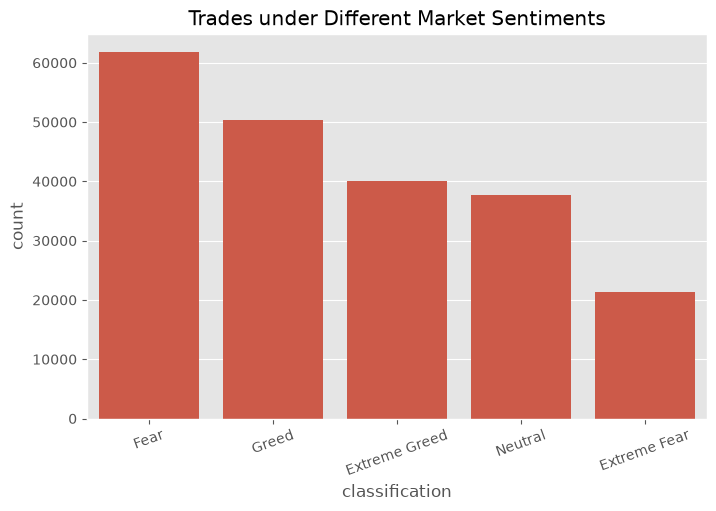

Market Sentiment Distribution

Interpretation:

This chart shows the number of trades executed under each market sentiment category.
The trading activity is not evenly distributed across sentiments, indicating that market conditions influence trading frequency.
Higher trade counts during certain sentiment periods suggest increased market participation or volatility during those conditions.


In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.title("Trades under Different Market Sentiments")
plt.xticks(rotation=20)
plt.show()

print("""Market Sentiment Distribution

Interpretation:

This chart shows the number of trades executed under each market sentiment category.
The trading activity is not evenly distributed across sentiments, indicating that market conditions influence trading frequency.
Higher trade counts during certain sentiment periods suggest increased market participation or volatility during those conditions.""")

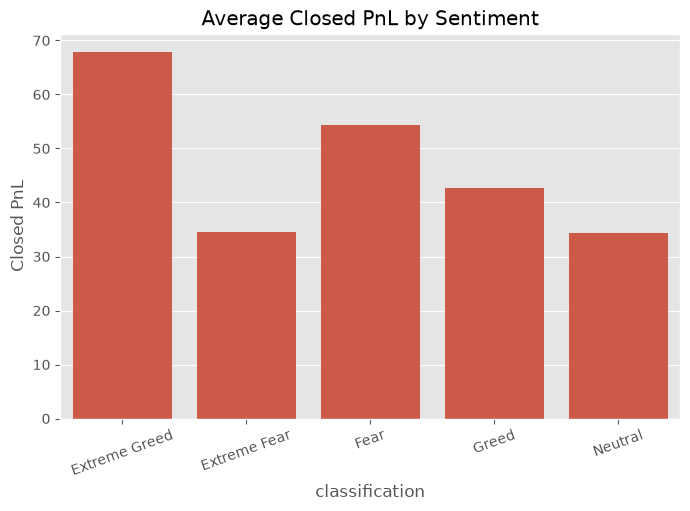

Average Profit by Sentiment

Interpretation:

This visualization compares the average realized profit (Closed PnL) across different market sentiments.
The differences in average profitability suggest that market sentiment influences trading outcomes.
Combined with the ANOVA results (p < 0.001), these differences are statistically significant rather than random.


In [94]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="classification",
    y="Closed PnL",
    estimator="mean",
    errorbar=None
)

plt.title("Average Closed PnL by Sentiment")
plt.xticks(rotation=20)
plt.show()

print("""Average Profit by Sentiment

Interpretation:

This visualization compares the average realized profit (Closed PnL) across different market sentiments.
The differences in average profitability suggest that market sentiment influences trading outcomes.
Combined with the ANOVA results (p < 0.001), these differences are statistically significant rather than random.""")

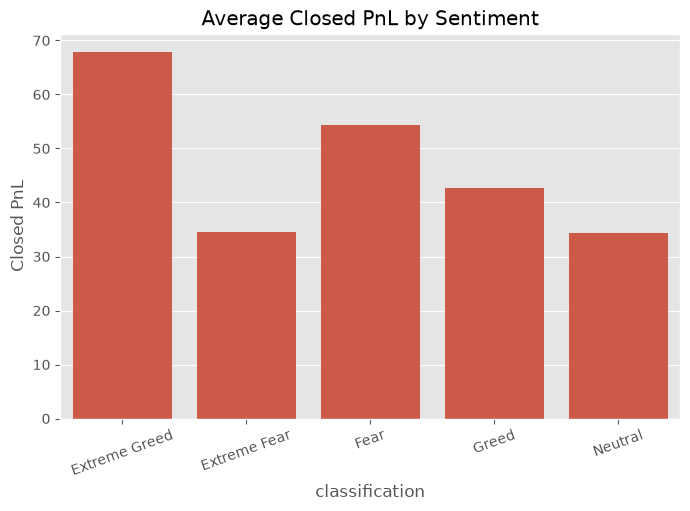

Interpretation:

This visualization compares the average realized profit (Closed PnL) across different market sentiments.
The differences in average profitability suggest that market sentiment influences trading outcomes.
Combined with the ANOVA results (p < 0.001), these differences are statistically significant rather than random.


In [91]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="classification",
    y="Closed PnL",
    estimator="mean",
    errorbar=None
)

plt.title("Average Closed PnL by Sentiment")
plt.xticks(rotation=20)
plt.show()

print("""Interpretation:

This visualization compares the average realized profit (Closed PnL) across different market sentiments.
The differences in average profitability suggest that market sentiment influences trading outcomes.
Combined with the ANOVA results (p < 0.001), these differences are statistically significant rather than random.""")

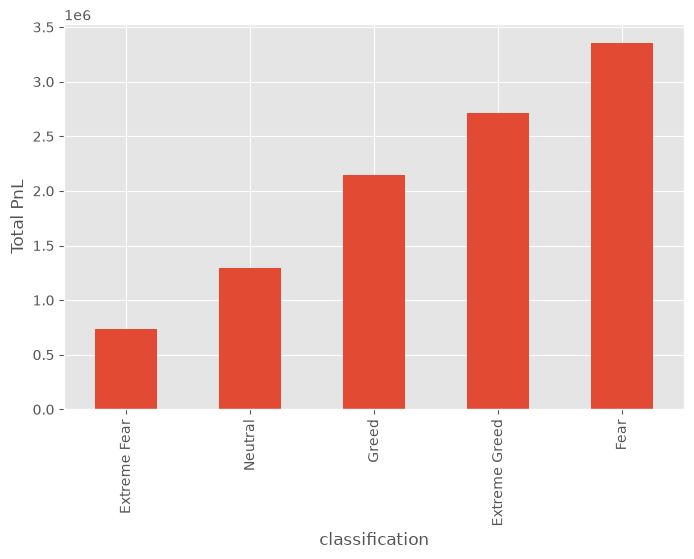

Total Profit by Sentiment

Interpretation:

Total profit measures the cumulative profitability generated under each sentiment category.
A higher total PnL indicates that traders collectively earned more during that market condition.
Since total profit is also influenced by the number of trades, it should be interpreted alongside trade volume.


In [95]:
merged.groupby("classification")["Closed PnL"]\
      .sum()\
      .sort_values()\
      .plot(
          kind="bar",
          figsize=(8,5)
      )

plt.ylabel("Total PnL")
plt.show()
print("""Total Profit by Sentiment

Interpretation:

Total profit measures the cumulative profitability generated under each sentiment category.
A higher total PnL indicates that traders collectively earned more during that market condition.
Since total profit is also influenced by the number of trades, it should be interpreted alongside trade volume.""")

In [70]:
win_rate = merged.groupby("classification")["IsWin"].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: IsWin, dtype: float64


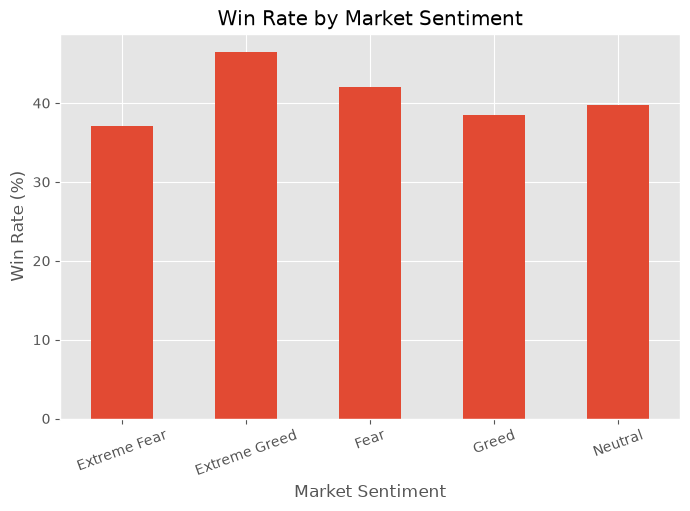

Win Rate by Sentiment

Interpretation:

Win rate represents the percentage of trades that closed with a positive profit.
Comparing win rates across sentiment categories helps identify market conditions where traders were more consistently successful.
Win rate complements average PnL by measuring consistency rather than profit magnitude.


In [96]:
win_rate.plot(kind="bar", figsize=(8,5))

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=20)
plt.show()

print("""Win Rate by Sentiment

Interpretation:

Win rate represents the percentage of trades that closed with a positive profit.
Comparing win rates across sentiment categories helps identify market conditions where traders were more consistently successful.
Win rate complements average PnL by measuring consistency rather than profit magnitude.""")

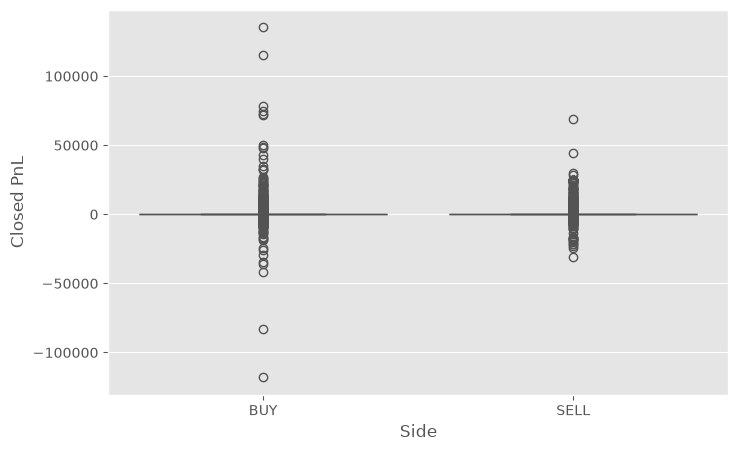

BUY vs SELL Performance

Interpretation:

The boxplot compares the distribution of realized profits for BUY and SELL trades.
The spread of each box indicates the variability of trading outcomes, while the median shows the typical profit level.
Outliers highlight occasional trades with exceptionally high profits or losses.


In [98]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="Side",
    y="Closed PnL"
)

plt.show()
print("""BUY vs SELL Performance

Interpretation:

The boxplot compares the distribution of realized profits for BUY and SELL trades.
The spread of each box indicates the variability of trading outcomes, while the median shows the typical profit level.
Outliers highlight occasional trades with exceptionally high profits or losses.""")

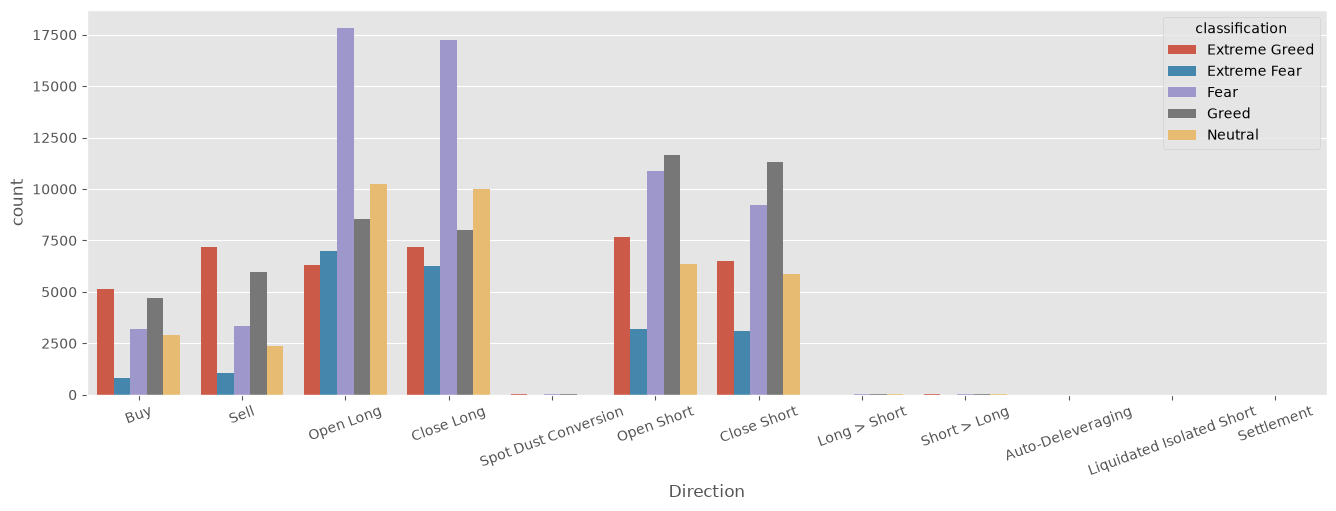

Direction Analysis

Interpretation:

This chart shows how different trading directions were distributed across market sentiment categories.
Changes in trading direction under different sentiments may indicate shifts in trader behavior and market expectations.
It provides insight into whether traders became more aggressive or defensive under specific market conditions.


In [99]:
plt.figure(figsize=(16, 5))   # (width, height)

sns.countplot(
    data=merged,
    x="Direction",
    hue="classification"
)

plt.xticks(rotation=20)
plt.show()
print("""Direction Analysis

Interpretation:

This chart shows how different trading directions were distributed across market sentiment categories.
Changes in trading direction under different sentiments may indicate shifts in trader behavior and market expectations.
It provides insight into whether traders became more aggressive or defensive under specific market conditions.""")

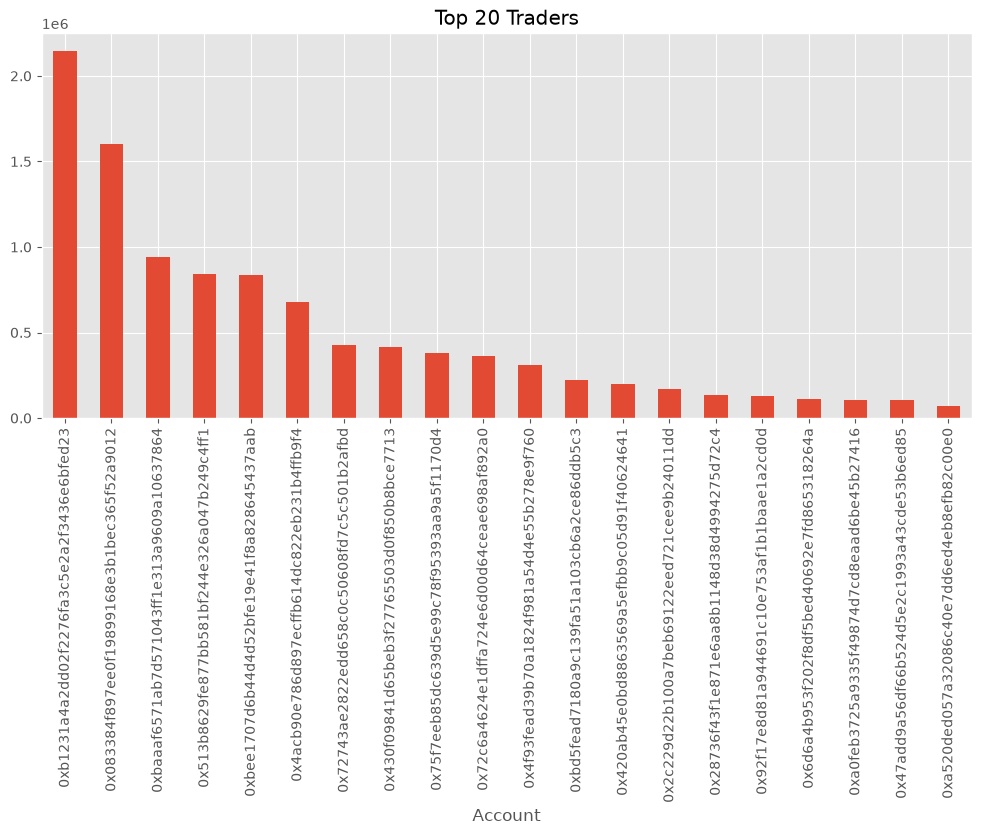

Top 20 Traders

Interpretation:

This chart identifies the highest-performing accounts based on cumulative realized profit.
A small number of traders generating a significant portion of total profits may indicate unequal performance across participants.
These accounts can be further analyzed to understand successful trading patterns and strategies.


In [100]:
top = merged.groupby("Account")["Closed PnL"]\
            .sum()\
            .sort_values(ascending=False)\
            .head(20)

top.plot(kind="bar", figsize=(12,5))

plt.title("Top 20 Traders")
plt.show()

print("""Top 20 Traders

Interpretation:

This chart identifies the highest-performing accounts based on cumulative realized profit.
A small number of traders generating a significant portion of total profits may indicate unequal performance across participants.
These accounts can be further analyzed to understand successful trading patterns and strategies.""")

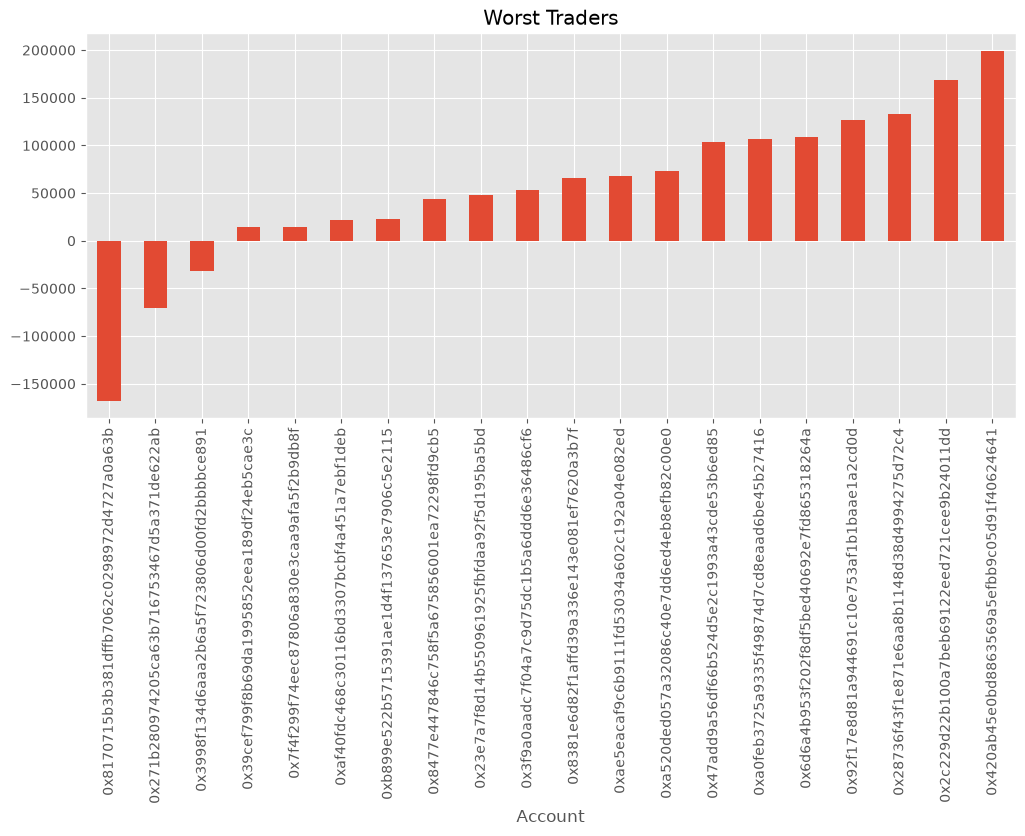

Worst 20 Traders

Interpretation:

This visualization highlights accounts with the largest cumulative losses.
Persistent negative performance may indicate ineffective trading strategies or excessive risk-taking.
Identifying these accounts can help evaluate common characteristics associated with poor performance.


In [101]:
bottom = merged.groupby("Account")["Closed PnL"]\
               .sum()\
               .sort_values()\
               .head(20)

bottom.plot(kind="bar", figsize=(12,5))

plt.title("Worst Traders")
plt.show()

print("""Worst 20 Traders

Interpretation:

This visualization highlights accounts with the largest cumulative losses.
Persistent negative performance may indicate ineffective trading strategies or excessive risk-taking.
Identifying these accounts can help evaluate common characteristics associated with poor performance.""")

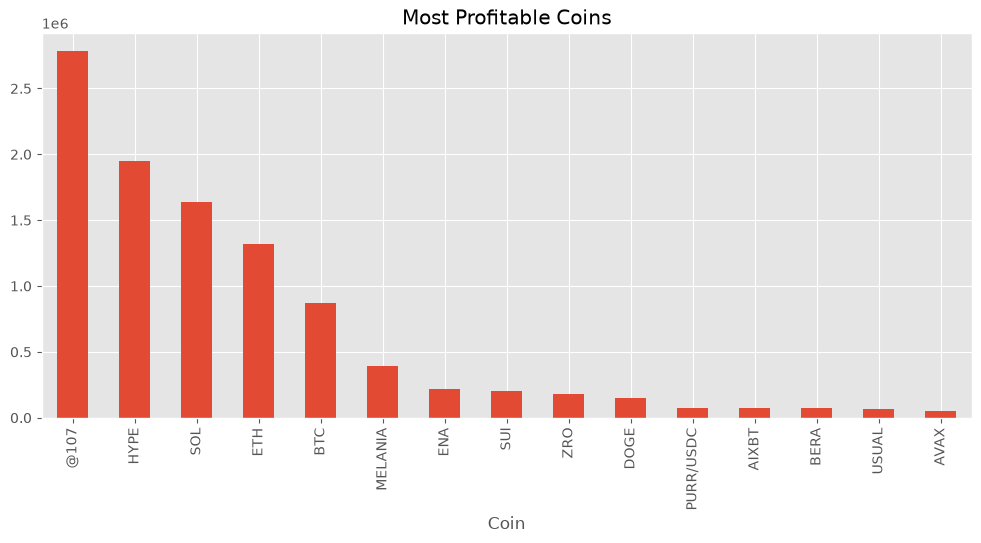

Best Coins

Interpretation:

This chart ranks cryptocurrency assets based on cumulative realized profit.
Some assets consistently generated higher profits than others, suggesting differences in trading opportunities and volatility.
Asset selection appears to have a meaningful impact on overall trading performance.


In [102]:
coin = merged.groupby("Coin")["Closed PnL"]\
             .sum()\
             .sort_values(ascending=False)\
             .head(15)

coin.plot(kind="bar", figsize=(12,5))

plt.title("Most Profitable Coins")
plt.show()
print("""Best Coins

Interpretation:

This chart ranks cryptocurrency assets based on cumulative realized profit.
Some assets consistently generated higher profits than others, suggesting differences in trading opportunities and volatility.
Asset selection appears to have a meaningful impact on overall trading performance.""")

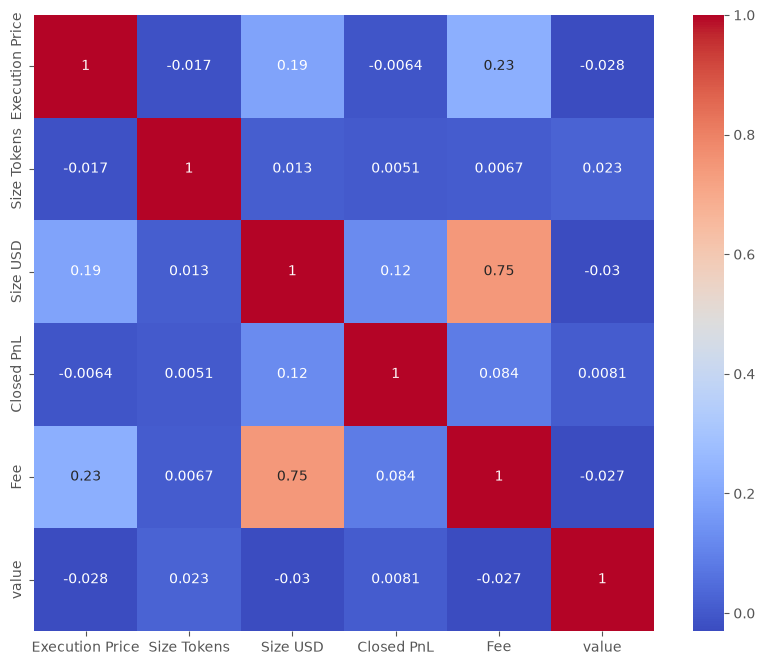

Correlation Heatmap

Interpretation:

The heatmap measures linear relationships between numerical variables in the dataset.
Strong positive or negative correlations indicate variables that move together, while values close to zero indicate weak relationships.
Understanding these relationships helps identify the key factors influencing trading profitability.


In [103]:
plt.figure(figsize=(10,8))

sns.heatmap(
    merged[[
        "Execution Price",
        "Size Tokens",
        "Size USD",
        "Closed PnL",
        "Fee",
        "value"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

print("""Correlation Heatmap

Interpretation:

The heatmap measures linear relationships between numerical variables in the dataset.
Strong positive or negative correlations indicate variables that move together, while values close to zero indicate weak relationships.
Understanding these relationships helps identify the key factors influencing trading profitability.""")

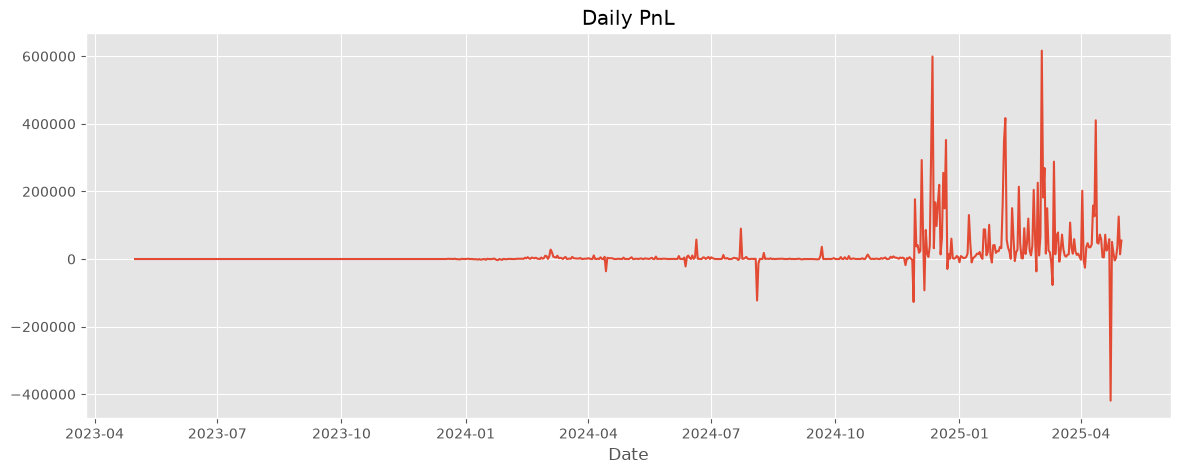

Daily Profit Trend

Interpretation:

This time-series chart illustrates how total daily realized profit changed over the observation period.
Large fluctuations indicate periods of increased market volatility and changing trading performance.
Trend analysis helps identify profitable periods as well as sustained drawdowns.


In [104]:
daily = merged.groupby("Date")["Closed PnL"].sum()

daily.plot(figsize=(14,5))

plt.title("Daily PnL")
plt.show()

print("""Daily Profit Trend

Interpretation:

This time-series chart illustrates how total daily realized profit changed over the observation period.
Large fluctuations indicate periods of increased market volatility and changing trading performance.
Trend analysis helps identify profitable periods as well as sustained drawdowns.""")

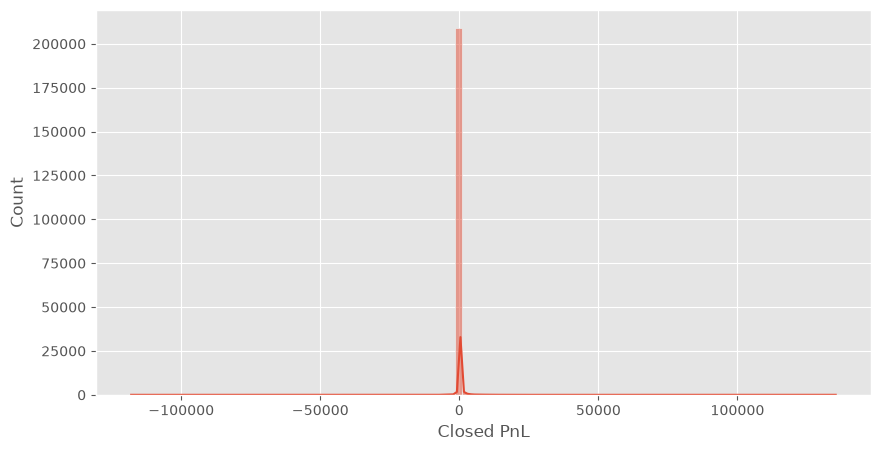

PnL Distribution

Interpretation:

The distribution of Closed PnL is highly skewed, with most trades generating little or no realized profit and a small number producing large gains or losses.
This pattern is common in financial trading datasets, where extreme outcomes occur infrequently.
The skewness suggests that median profit may be a more representative metric than the mean.


In [105]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged["Closed PnL"],
    bins=100,
    kde=True
)

plt.show()
print("""PnL Distribution

Interpretation:

The distribution of Closed PnL is highly skewed, with most trades generating little or no realized profit and a small number producing large gains or losses.
This pattern is common in financial trading datasets, where extreme outcomes occur infrequently.
The skewness suggests that median profit may be a more representative metric than the mean.""")

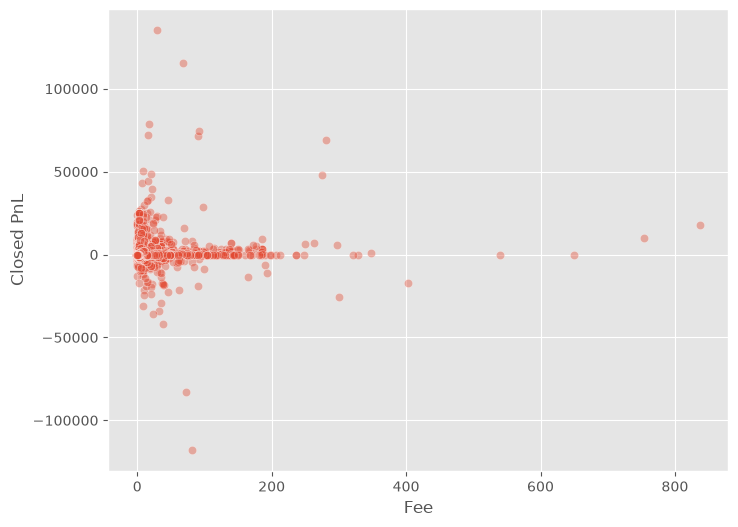

Fee vs Profit

Interpretation:

This scatter plot examines whether higher transaction fees are associated with higher profitability.
The absence of a clear trend would suggest that paying larger fees alone does not guarantee improved returns.
Further analysis is required to determine whether larger fees simply reflect larger trade sizes.



In [107]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Fee",
    y="Closed PnL",
    alpha=0.4
)

plt.show()
print("""Fee vs Profit

Interpretation:

This scatter plot examines whether higher transaction fees are associated with higher profitability.
The absence of a clear trend would suggest that paying larger fees alone does not guarantee improved returns.
Further analysis is required to determine whether larger fees simply reflect larger trade sizes.
""")

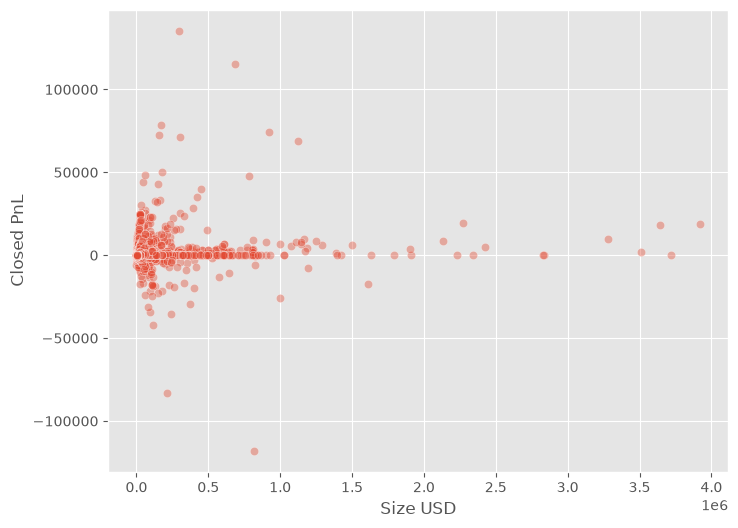

Trade Size vs Profit

Interpretation:

This visualization explores the relationship between trade size and realized profit.
Larger positions may result in both higher profits and larger losses, reflecting increased risk exposure.
The broad dispersion indicates that trade size alone is not sufficient to predict profitability.


In [108]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Size USD",
    y="Closed PnL",
    alpha=0.4
)

plt.show()
print("""Trade Size vs Profit

Interpretation:

This visualization explores the relationship between trade size and realized profit.
Larger positions may result in both higher profits and larger losses, reflecting increased risk exposure.
The broad dispersion indicates that trade size alone is not sufficient to predict profitability.""")